Raw shapes:
X_raw: (1, 2000, 1, 100)
Z_raw: (1, 2000, 1, 25)
W_raw: (1, 100, 25)
X reshaped: (2000, 100)
Z reshaped: (2000, 25)
W squeezed: (100, 25)
T = 2000, d_x = 100, d_z = 25


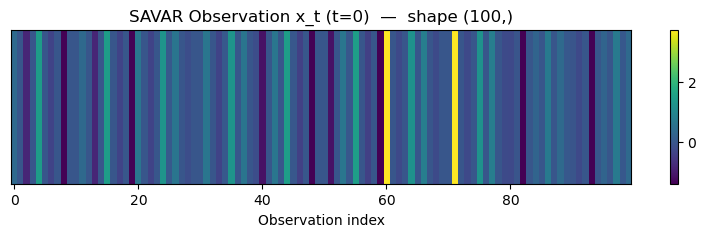

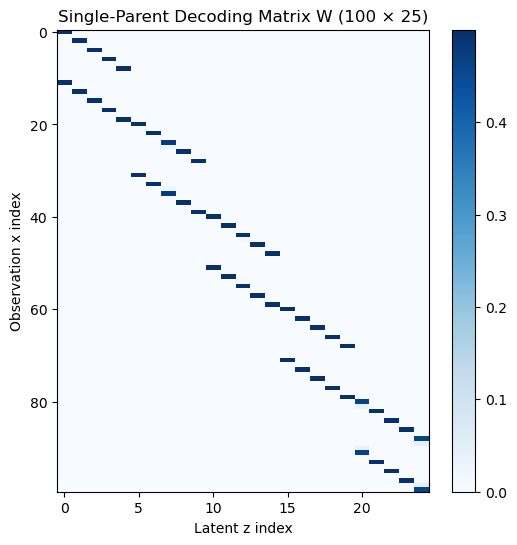

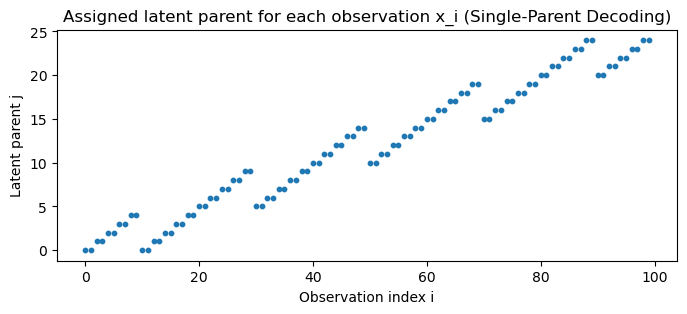

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------
# Load uploaded files
# ----------------------
X_raw = np.load('dataset/savar_N25_med-hard_seed0/data_x.npy')       # shape [T, d_x]
Z_raw = np.load('dataset/savar_N25_med-hard_seed0/data_z.npy')       # shape [T, d_z]
W_raw = np.load('dataset/savar_N25_med-hard_seed0/graph_w.npy')      # shape [d_x, d_z]

print("Raw shapes:")
print("X_raw:", X_raw.shape)
print("Z_raw:", Z_raw.shape)
print("W_raw:", W_raw.shape)

# ---- X: 把時間跟 feature 保留下來，其它都展平 ----
# 最後想要 X: (T, d_x)
X = X_raw.reshape(-1, X_raw.shape[-1])
print("X reshaped:", X.shape)

# ---- Z: 同理，只保留 (T, d_z) ----
Z = Z_raw.reshape(-1, Z_raw.shape[-1])
print("Z reshaped:", Z.shape)

# ---- W: 去掉 batch 維度，應該變成 (d_x, d_z) ----
W = W_raw.squeeze()
print("W squeezed:", W.shape)

assert W.ndim == 2, f"W should be 2D (d_x, d_z), got {W.shape}"

T, d_x = X.shape
_, d_z = Z.shape

print(f"T = {T}, d_x = {d_x}, d_z = {d_z}")
# ----------------------
# 1. Visualize one SAVAR sample x_t
# ----------------------
# For SAVAR N25, d_x = 25 → 可以 reshape 成 5×5 的 pseudo-grid
t = 0
plt.figure(figsize=(10,2))
plt.title(f"SAVAR Observation x_t (t={t})  —  shape (100,)")
plt.imshow(X[t].reshape(1, -1), aspect="auto", cmap="viridis")
plt.colorbar()
plt.xlabel("Observation index")
plt.yticks([])
plt.show()

# ----------------------
# 2. Visualize W_true (Single-Parent Decoding blocks)
# ----------------------
plt.figure(figsize=(6,6))
plt.title("Single-Parent Decoding Matrix W (100 × 25)")
plt.imshow(W, cmap="Blues", aspect="auto")
plt.colorbar()
plt.xlabel("Latent z index")
plt.ylabel("Observation x index")
plt.show()

# Optionally highlight the argmax parent of each x_i
parents = np.argmax(W, axis=1)

plt.figure(figsize=(8,3))
plt.title("Assigned latent parent for each observation x_i (Single-Parent Decoding)")
plt.scatter(np.arange(len(parents)), parents, s=10)
plt.xlabel("Observation index i")
plt.ylabel("Latent parent j")
plt.show()